# Representational bias study — UCI Bank Marketing (marital)

Non-fairness-literature counterpart to the Adult/sex and COMPAS/race sweeps. Same
protocol: build a perfectly balanced 25/25/25/25 base over `(marital_married, Y)`,
then progressively shrink the two unprivileged cells (single + divorced) while
keeping the privileged cells (married) fixed. Within-group `P(Y=1) = 0.5` is held
constant in both groups — only group **size** changes.

Sensitive attribute: **`marital_married`**, derived from the original 3-level
`marital` column. `1 = married = privileged`, `0 = single or divorced = unprivileged`.
Target: **`Y`** = `(y == "yes")`, i.e. did the client subscribe to the term deposit.

**Source:** `bank-full.csv` (classic 17-feature variant, 45,211 rows), loaded
inline — no `skfair.datasets.load_bank()`; this dataset is just a one-off
methodological showcase. The raw CSV lives at `datasets/bank/bank-full.csv`
alongside the generated level CSVs.

**Preprocessing decisions:**
- `duration` is **dropped** — UCI documents it as a leak (only known after the call).
- `marital` → `marital_married` binary, original column dropped.
- Remaining categoricals one-hot/numerically encoded via `preprocess_frame`
  (the same utility `load_adult` uses), with `marital_married` excluded so the
  sens column stays a clean 0/1.

Bank has the most sample headroom of the four datasets in the study; at `p_u=0.1`
each unprivileged cell still has ~253 rows (~51 per held-out fold under 5-fold CV).

## 1. Define the sweep grid

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

from skfair.datasets._preprocessing import preprocess_frame

DATASET_NAME = "bank"
SENS_ATTR = "marital_married"
PRIV_GROUP = 1
BASE_SEED = 42

P_U_LEVELS = [1.0, 0.75, 0.5, 0.25, 0.1]

DATA_DIR = Path("datasets") / DATASET_NAME
OUT_DIR = Path("../outputs/representational_study")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

force = False

## 2. Load + inline preprocessing

Read `bank-full.csv` (semicolon-separated), drop the `duration` leak, derive
`marital_married` as the sens column, encode `y` → `Y` (0/1), then run
`preprocess_frame` over the rest. The sens column is kept out of the encoder
so it stays a clean 0/1 indicator (same trick `load_adult` uses for `sex`).

In [2]:
raw = pd.read_csv(DATA_DIR / "bank-full.csv", sep=";")
print(f"raw shape: {raw.shape}")

raw = raw.drop(columns=["duration"])  # UCI-documented leak
raw[SENS_ATTR] = (raw["marital"] == "married").astype(int)
raw = raw.drop(columns=["marital"])
raw["Y"] = (raw["y"] == "yes").astype(int)
raw = raw.drop(columns=["y"])

y_full = raw["Y"]
X_full = preprocess_frame(raw.drop(columns=["Y"]), exclude_cols=[SENS_ATTR])

assert "duration" not in X_full.columns
assert "marital" not in X_full.columns
assert set(y_full.unique()) <= {0, 1}
assert set(X_full[SENS_ATTR].unique()) == {0, 1}

print(f"X shape after preprocessing: {X_full.shape}")
print(f"Y rate overall: {y_full.mean():.3f}")
print(f"sens={SENS_ATTR} (married=1) share: {X_full[SENS_ATTR].mean():.3f}")

raw shape: (45211, 17)
X shape after preprocessing: (45211, 40)
Y rate overall: 0.117
sens=marital_married (married=1) share: 0.602


## 3. Build the balanced 25/25/25/25 base

Count the four `(marital_married, Y)` cells, take the smallest as `n_per_cell`,
random-sample that many rows from each cell with `random_state=BASE_SEED`. The
base has `P(marital_married=1) = P(Y=1) = P(Y=1|marital_married=0) = P(Y=1|marital_married=1) = 0.5`
— no historical bias, no representational bias, the reference point.

In [3]:
df_full = X_full.copy()
df_full["Y"] = np.asarray(y_full).astype(int)

cells = {(a, y): df_full[(df_full[SENS_ATTR] == a) & (df_full["Y"] == y)]
         for a in (0, 1) for y in (0, 1)}

print(f"({SENS_ATTR}, Y) cell counts:")
for k, v in cells.items():
    print(f"  {k}: {len(v)}")

n_per_cell = min(len(v) for v in cells.values())
print(f"\nlimiting cell -> n_per_cell = {n_per_cell}")

rng = np.random.RandomState(BASE_SEED)
base = pd.concat(
    [df.sample(n=n_per_cell, random_state=rng.randint(0, 2**31 - 1))
     for df in cells.values()],
    ignore_index=True,
)

assert (base.groupby([SENS_ATTR, "Y"]).size() == n_per_cell).all(), \
    f"balanced base must have exactly n_per_cell rows in every ({SENS_ATTR}, Y) cell"
print(f"\nbase shape: {base.shape}  (4 × {n_per_cell} = {4 * n_per_cell})")

(marital_married, Y) cell counts:
  (0, 0): 15463
  (0, 1): 2534
  (1, 0): 24459
  (1, 1): 2755

limiting cell -> n_per_cell = 2534



base shape: (10136, 41)  (4 × 2534 = 10136)


## 4. Generate the 5 level CSVs

For each `p_u`, keep both privileged cells at full `n_per_cell` and randomly
downsample each unprivileged cell to `int(n_per_cell * p_u)` rows. Per-level
seed = `BASE_SEED + i` so the sweep is fully deterministic and reproducible.
Idempotent: skipped if the CSV already exists (`force=True` regenerates).

In [4]:
priv_rows = base[base[SENS_ATTR] == PRIV_GROUP]
unpriv_rows = base[base[SENS_ATTR] != PRIV_GROUP]

for i, p_u in enumerate(P_U_LEVELS):
    tag = f"{int(p_u * 100):03d}"
    out = DATA_DIR / f"{DATASET_NAME}_p_u_{tag}.csv"
    if out.exists() and not force:
        print(f"skip {out.name} (exists)")
        continue

    k = int(n_per_cell * p_u)
    rng_lvl = np.random.RandomState(BASE_SEED + i)
    unpriv_kept = pd.concat(
        [g.sample(n=k, random_state=rng_lvl.randint(0, 2**31 - 1))
         for _, g in unpriv_rows.groupby("Y", sort=True)],
        ignore_index=True,
    )
    level = pd.concat([priv_rows, unpriv_kept], ignore_index=True)

    counts = level.groupby([SENS_ATTR, "Y"]).size().to_dict()
    assert counts[(PRIV_GROUP, 0)] == n_per_cell
    assert counts[(PRIV_GROUP, 1)] == n_per_cell
    assert counts[(1 - PRIV_GROUP, 0)] == k
    assert counts[(1 - PRIV_GROUP, 1)] == k

    level.to_csv(out, index=False)
    print(f"wrote {out.name}  shape={level.shape}  unpriv_per_cell={k}")

skip bank_p_u_100.csv (exists)
skip bank_p_u_075.csv (exists)
skip bank_p_u_050.csv (exists)
skip bank_p_u_025.csv (exists)
skip bank_p_u_010.csv (exists)


## 5. Load each level into the custom-dataset shape

`Experiment` accepts a list of dicts of the form
`{"name", "data": (X, y), "sens_attr", "priv_group"}`.

In [5]:
def load_level(csv_path, name):
    df = pd.read_csv(csv_path)
    y = df["Y"].astype(int)
    X = df.drop(columns=["Y"])
    return {"name": name, "data": (X, y), "sens_attr": SENS_ATTR, "priv_group": PRIV_GROUP}

datasets = [
    load_level(DATA_DIR / f"{DATASET_NAME}_p_u_{int(p * 100):03d}.csv",
               f"{DATASET_NAME}_p_u_{int(p * 100):03d}")
    for p in P_U_LEVELS
]
[(d["name"], d["data"][0].shape, int(d["data"][1].sum())) for d in datasets]

[('bank_p_u_100', (10136, 40), 5068),
 ('bank_p_u_075', (8868, 40), 4434),
 ('bank_p_u_050', (7602, 40), 3801),
 ('bank_p_u_025', (6334, 40), 3167),
 ('bank_p_u_010', (5574, 40), 2787)]

## 6. Build the Experiment

Methods / classifiers / metrics / CV come straight from `config.yaml`
(identical to `biasondemand`, `adult.ipynb`, and `compas.ipynb`).

In [6]:
from skfair.experimentation import Experiment

with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

exp = Experiment(
    datasets=datasets,
    methods=cfg["methods"],
    classifiers=cfg["classifiers"],
    metrics=cfg["metrics"],
    n_splits=cfg["cv"]["n_splits"],
    random_state=cfg["cv"]["random_state"],
    stratify=cfg["cv"].get("stratify", "y"),
    audit_bias=cfg["audit"]["bias"],
    audit_fairness=cfg["audit"]["fairness"],
    save_results_csv=cfg["save"]["results_csv"],
    save_object_pkl=cfg["save"]["object_pkl"],
    save_report_html=cfg["save"]["report_html"],
    save_path=str(OUT_DIR / DATASET_NAME),
)

## 7. Run

5 datasets × 12 methods × 4 classifiers × 5 folds = **1200 fits**. Outputs
land in `../outputs/representational_study/bank.{csv,pkl,html}`.

In [7]:
results = exp.run(verbose=True)
results


Dataset: bank_p_u_100


  Baseline                       | LogReg  acc=0.688  spd=0.010


  Baseline                       | DecisionTree  acc=0.626  spd=-0.013


  Baseline                       | SVC  acc=0.717  spd=0.018


  Baseline                       | XGBoost  acc=0.709  spd=0.013


...

  FairMask                       | LogReg  acc=0.694  spd=0.005


  FairMask                       | DecisionTree  acc=0.622  spd=-0.007


  FairMask                       | SVC  acc=0.716  spd=-0.015


  FairMask                       | XGBoost  acc=0.701  spd=0.038


,dataset,method,classifier,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
0,bank_p_u_100,Baseline,LogReg,0.688438,0.688435,0.725572,0.606353,0.660494,1.025266,0.009862,0.002752,0.009860,-0.016967,1.085219,0.990587,1.007066,-0.002752
1,bank_p_u_100,Baseline,DecisionTree,0.626085,0.626087,0.624332,0.633589,0.628852,0.975481,-0.012630,-0.028800,-0.012635,-0.003530,1.010801,0.975004,0.956110,0.028800
2,bank_p_u_100,Baseline,SVC,0.717344,0.717346,0.777372,0.609318,0.683006,1.048570,0.018346,-0.001588,0.018340,-0.038268,1.276700,0.973205,0.997999,0.001588
3,bank_p_u_100,Baseline,XGBoost,0.708761,0.708761,0.734204,0.654700,0.692068,1.030340,0.013017,0.001565,0.013013,-0.024460,1.116836,0.984457,1.003334,-0.001565
4,bank_p_u_100,FairSmote,LogReg,0.688536,0.688534,0.725853,0.606155,0.660492,1.024957,0.009665,0.002358,0.009663,-0.016968,1.084731,0.990240,1.006469,-0.002358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,bank_p_u_010,FairBalanceClassifier,XGBoost,0.693042,0.693045,0.712943,0.646225,0.677875,1.039560,0.016577,-0.050356,0.016421,-0.083197,1.335470,0.906212,0.927782,0.050356
236,bank_p_u_010,FairMask,LogReg,0.693939,0.693945,0.732458,0.610711,0.665982,1.011111,0.004510,-0.058851,0.004367,-0.067585,1.326135,0.911111,0.906837,0.058851
237,bank_p_u_010,FairMask,DecisionTree,0.622172,0.622178,0.620468,0.630061,0.625102,0.988317,-0.006522,-0.066963,-0.006483,-0.053996,1.150634,0.903789,0.893125,0.066963
238,bank_p_u_010,FairMask,SVC,0.715646,0.715653,0.771586,0.612506,0.682707,0.962683,-0.014905,-0.069384,-0.014976,-0.039431,1.245947,0.925687,0.889662,0.069384


## 8. Summary tables

In [8]:
report = exp.to_report()
tables = report.summary_tables()
for name, df in tables.items():
    print(f"--- {name} ---")
    display(df)

--- bank_p_u_010 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.6829,0.6829,0.7112,0.6261,0.6645,1.0117,0.0058,-0.0530,0.0057,-0.0645,1.2740,0.9154,0.9168,0.0530
DisparateImpactRemover,0.6818,0.6818,0.7097,0.6273,0.6640,0.9950,-0.0021,-0.0694,-0.0022,-0.0650,1.2716,0.9025,0.8923,0.0694
FAWOS,0.6823,0.6823,0.7104,0.6258,0.6639,1.0092,0.0045,-0.0505,0.0043,-0.0591,1.2537,0.9210,0.9209,0.0505
FairBalanceClassifier,0.6826,0.6826,0.7117,0.6234,0.6634,1.0096,0.0047,-0.0588,0.0045,-0.0678,1.2924,0.9087,0.9082,0.0588
FairMask,0.6831,0.6831,0.7114,0.6269,0.6650,1.0118,0.0052,-0.0517,0.0051,-0.0618,1.2741,0.9182,0.9185,0.0517
FairOversampling,0.6822,0.6822,0.7102,0.6262,0.6641,0.9944,-0.0020,-0.0563,-0.0022,-0.0520,1.2244,0.9221,0.9116,0.0563
FairSmote,0.6778,0.6778,0.7070,0.6194,0.6586,1.0475,0.0175,-0.0522,0.0173,-0.0868,1.4219,0.9001,0.9204,0.0522
FairwayRemover,0.6778,0.6778,0.6968,0.6381,0.6650,0.9787,-0.0092,-0.0792,-0.0094,-0.0605,1.2339,0.8988,0.8784,0.0792
HeterogeneousFOS,0.6790,0.6790,0.7096,0.6156,0.6579,1.0111,0.0043,-0.0622,0.0041,-0.0704,1.3360,0.9050,0.9019,0.0622


--- bank_p_u_025 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.6823,0.6823,0.7109,0.6258,0.6639,1.0233,0.0104,-0.0195,0.0104,-0.0403,1.1729,0.9570,0.9702,0.0195
DisparateImpactRemover,0.6804,0.6804,0.7088,0.6243,0.6622,1.0277,0.0123,-0.0132,0.0123,-0.0378,1.1664,0.9633,0.9798,0.0132
FAWOS,0.6829,0.6829,0.7114,0.6266,0.6646,1.0274,0.0123,-0.0201,0.0122,-0.0446,1.1875,0.9533,0.9693,0.0201
FairBalanceClassifier,0.6821,0.6821,0.7102,0.6266,0.6641,1.0235,0.0101,-0.0191,0.0101,-0.0393,1.1706,0.9576,0.9706,0.0191
FairMask,0.6824,0.6824,0.7130,0.6226,0.6629,1.0480,0.0207,-0.0076,0.0207,-0.0490,1.2284,0.9598,0.9888,0.0076
FairOversampling,0.6827,0.6827,0.7113,0.6262,0.6643,1.0217,0.0098,-0.0210,0.0097,-0.0404,1.1736,0.9558,0.9677,0.0210
FairSmote,0.6808,0.6808,0.7107,0.6209,0.6612,1.0416,0.0170,-0.0164,0.0170,-0.0504,1.2480,0.9527,0.9757,0.0164
FairwayRemover,0.6791,0.6791,0.7012,0.6344,0.6646,1.0249,0.0103,-0.0184,0.0102,-0.0389,1.1722,0.9590,0.9733,0.0184
HeterogeneousFOS,0.6810,0.6810,0.7090,0.6237,0.6622,1.0077,0.0027,-0.0282,0.0027,-0.0336,1.1569,0.9556,0.9560,0.0282


--- bank_p_u_050 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.6832,0.6832,0.7128,0.6251,0.6643,1.0245,0.0098,-0.0088,0.0098,-0.0284,1.1558,0.9745,0.9867,0.0088
DisparateImpactRemover,0.6829,0.6829,0.7123,0.6246,0.6639,1.0168,0.0061,-0.0101,0.0061,-0.0224,1.1259,0.9771,0.9844,0.0101
FAWOS,0.6842,0.6842,0.7137,0.6267,0.6656,1.0249,0.0100,-0.0062,0.0100,-0.0261,1.1443,0.9779,0.9908,0.0062
FairBalanceClassifier,0.6837,0.6837,0.7135,0.6246,0.6644,1.0236,0.0098,-0.0060,0.0098,-0.0256,1.1374,0.9782,0.9907,0.0060
FairMask,0.6830,0.6830,0.7132,0.6239,0.6638,1.0487,0.0197,-0.0017,0.0197,-0.0411,1.2266,0.9705,0.9978,0.0017
FairOversampling,0.6841,0.6841,0.7140,0.6258,0.6652,1.0229,0.0091,-0.0075,0.0091,-0.0257,1.1423,0.9773,0.9888,0.0075
FairSmote,0.6856,0.6856,0.7161,0.6239,0.6656,1.0134,0.0045,-0.0148,0.0045,-0.0238,1.1399,0.9729,0.9770,0.0148
FairwayRemover,0.6793,0.6793,0.7024,0.6312,0.6636,1.0366,0.0149,-0.0016,0.0149,-0.0315,1.1518,0.9764,0.9980,0.0016
HeterogeneousFOS,0.6842,0.6842,0.7129,0.6260,0.6653,1.0293,0.0117,-0.0076,0.0118,-0.0311,1.1664,0.9732,0.9891,0.0076


--- bank_p_u_075 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.6852,0.6852,0.7164,0.6250,0.6659,1.0143,0.0051,-0.0097,0.0051,-0.0200,1.1031,0.9785,0.9858,0.0097
DisparateImpactRemover,0.6864,0.6864,0.7191,0.6213,0.6651,1.0221,0.0088,-0.0029,0.0088,-0.0205,1.1039,0.9831,0.9962,0.0029
FAWOS,0.6852,0.6852,0.7164,0.6250,0.6659,1.0143,0.0051,-0.0097,0.0051,-0.0200,1.1031,0.9785,0.9858,0.0097
FairBalanceClassifier,0.6818,0.6818,0.7127,0.6213,0.6623,1.0251,0.0098,-0.0037,0.0098,-0.0233,1.1203,0.9806,0.9952,0.0037
FairMask,0.6840,0.6840,0.7161,0.6220,0.6640,1.0399,0.0155,-0.0001,0.0155,-0.0311,1.1723,0.9778,1.0013,0.0001
FairOversampling,0.6838,0.6837,0.7142,0.6248,0.6648,1.0123,0.0042,-0.0103,0.0042,-0.0187,1.0982,0.9790,0.9848,0.0103
FairSmote,0.6845,0.6845,0.7157,0.6229,0.6645,1.0234,0.0087,0.0005,0.0087,-0.0169,1.1014,0.9890,1.0025,-0.0005
FairwayRemover,0.6816,0.6816,0.7075,0.6292,0.6647,1.0339,0.0136,-0.0004,0.0136,-0.0276,1.1448,0.9807,1.0005,0.0004
HeterogeneousFOS,0.6845,0.6845,0.7148,0.6250,0.6653,1.0250,0.0099,-0.0076,0.0099,-0.0274,1.1415,0.9751,0.9890,0.0076


--- bank_p_u_100 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.6852,0.6852,0.7154,0.6260,0.6661,1.0199,0.0071,-0.0065,0.0071,-0.0208,1.1224,0.9808,0.9911,0.0065
DisparateImpactRemover,0.6856,0.6856,0.7154,0.6257,0.6662,1.0436,0.0185,0.0063,0.0185,-0.0308,1.1442,0.9826,1.0113,-0.0063
FAWOS,0.6841,0.6841,0.7141,0.6246,0.6648,1.0244,0.0092,-0.0020,0.0092,-0.0204,1.1170,0.9843,0.9985,0.0020
FairBalanceClassifier,0.6840,0.6840,0.7142,0.6249,0.6649,1.0247,0.0093,-0.0061,0.0093,-0.0248,1.1379,0.9783,0.9920,0.0061
FairMask,0.6853,0.6853,0.7162,0.6240,0.6654,1.0444,0.0173,0.0035,0.0173,-0.0311,1.1767,0.9808,1.0071,-0.0035
FairOversampling,0.6842,0.6842,0.7140,0.6254,0.6652,1.0220,0.0080,-0.0030,0.0080,-0.0189,1.1120,0.9845,0.9968,0.0030
FairSmote,0.6845,0.6845,0.7144,0.6261,0.6657,1.0225,0.0084,-0.0035,0.0084,-0.0203,1.1169,0.9834,0.9960,0.0035
FairwayRemover,0.6816,0.6816,0.7073,0.6292,0.6647,1.0267,0.0109,-0.0034,0.0109,-0.0251,1.1216,0.9797,0.9961,0.0034
HeterogeneousFOS,0.6856,0.6856,0.7158,0.6260,0.6664,1.0253,0.0097,-0.0038,0.0097,-0.0232,1.1294,0.9811,0.9956,0.0038


## 9. Trade-off and ranking plots

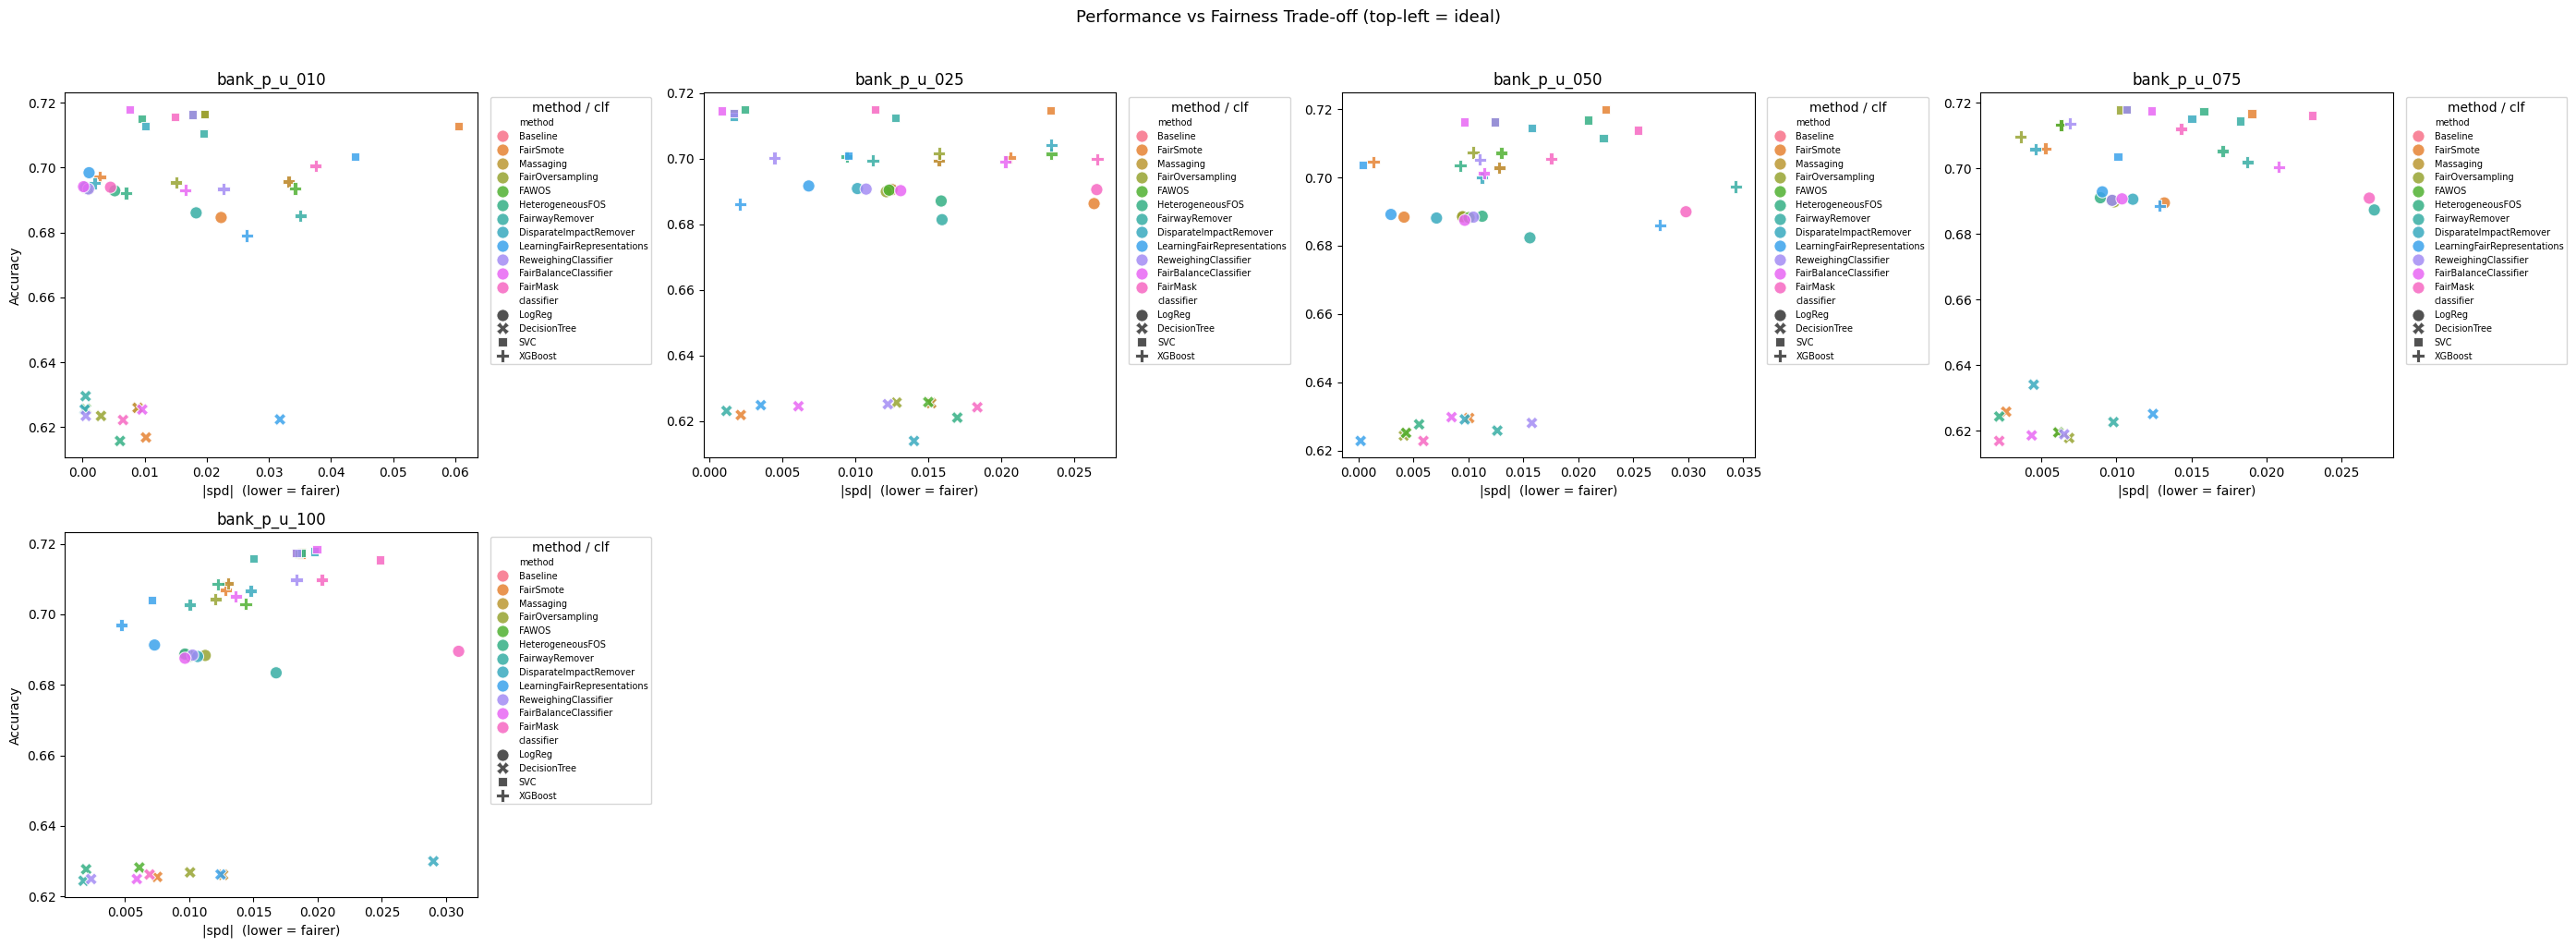

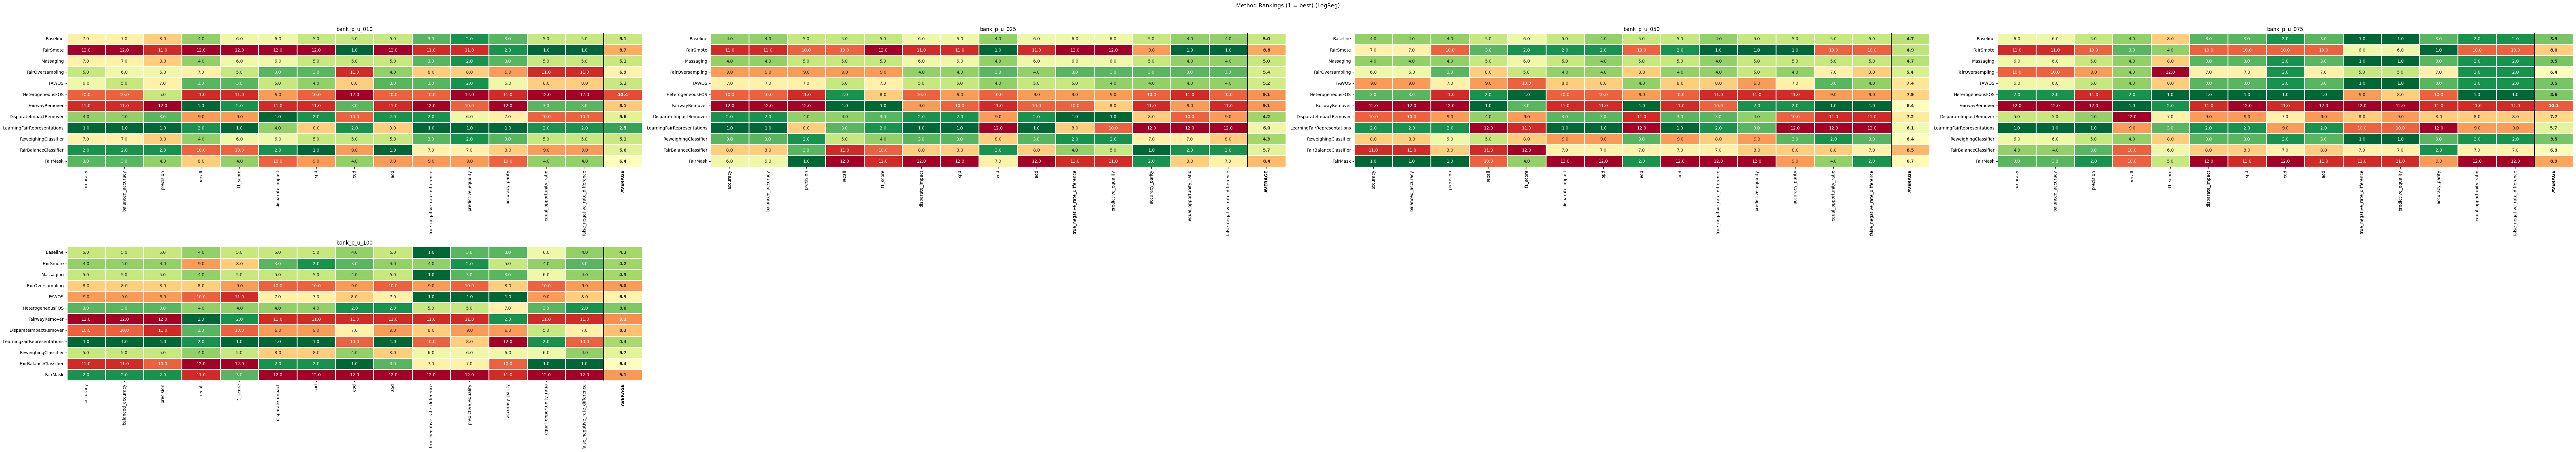

In [9]:
report.plot_tradeoff(fairness_metric="spd", performance_metric="accuracy");
report.plot_ranking(classifier="LogReg");

## 10. Headline view — fairness vs `p_u`

Parse `p_u` from the dataset name, then aggregate per (method, level). This is
the money chart: which methods hold fairness as the unprivileged group shrinks?
`Baseline` should worsen monotonically as `p_u` drops; preprocessing methods
that earn their keep should stay flatter. Bank's `p_u=0.1` should be the
smoothest tail of the three datasets thanks to its larger sample size.

In [10]:
df = results.copy()
df["p_u"] = df["dataset"].str.split("_p_u_").str[-1].astype(int) / 100

df.groupby(["method", "p_u"])[["spd", "disparate_impact", "eod", "accuracy"]].mean().round(3)

spd  disparate_impact    eod  accuracy
method                      p_u                                           
Baseline                    0.10  0.006             1.012 -0.053     0.683
                            0.25  0.010             1.023 -0.019     0.682
                            0.50  0.010             1.024 -0.009     0.683
                            0.75  0.005             1.014 -0.010     0.685
                            1.00  0.007             1.020 -0.007     0.685
DisparateImpactRemover      0.10 -0.002             0.995 -0.069     0.682
                            0.25  0.012             1.028 -0.013     0.680
                            0.50  0.006             1.017 -0.010     0.683
                            0.75  0.009             1.022 -0.003     0.686
                            1.00  0.019             1.044  0.006     0.686
FAWOS                       0.10  0.004             1.009 -0.050     0.682
                            0.25  0.012             1.027 -0.020     0.683
                            0.50  0.010             1.025 -0.006     0.684
                            0.75  0.005             1.014 -0.010     0.685
                            1.00  0.009             1.024 -0.002     0.684
FairBalanceClassifier       0.10  0.005             1.010 -0.059     0.683
                            0.25  0.010             1.024 -0.019     0.682
                            0.50  0.010             1.024 -0.006     0.684
                            0.75  0.010             1.025 -0.004     0.682
                            1.00  0.009             1.025 -0.006     0.684
FairMask                    0.10  0.005             1.012 -0.052     0.683
                            0.25  0.021             1.048 -0.008     0.682
                            0.50  0.020             1.049 -0.002     0.683
                            0.75  0.016             1.040 -0.000     0.684
                            1.00  0.017             1.044  0.004     0.685
FairOversampling            0.10 -0.002             0.994 -0.056     0.682
                            0.25  0.010             1.022 -0.021     0.683
                            0.50  0.009             1.023 -0.007     0.684
                            0.75  0.004             1.012 -0.010     0.684
                            1.00  0.008             1.022 -0.003     0.684
FairSmote                   0.10  0.017             1.047 -0.052     0.678
                            0.25  0.017             1.042 -0.016     0.681
                            0.50  0.004             1.013 -0.015     0.686
                            0.75  0.009             1.023  0.001     0.684
                            1.00  0.008             1.022 -0.003     0.684
FairwayRemover              0.10 -0.009             0.979 -0.079     0.678
                            0.25  0.010             1.025 -0.018     0.679
                            0.50  0.015             1.037 -0.002     0.679
                            0.75  0.014             1.034 -0.000     0.682
                            1.00  0.011             1.027 -0.003     0.682
HeterogeneousFOS            0.10  0.004             1.011 -0.062     0.679
                            0.25  0.003             1.008 -0.028     0.681
                            0.50  0.012             1.029 -0.008     0.684
                            0.75  0.010             1.025 -0.008     0.684
                            1.00  0.010             1.025 -0.004     0.686
LearningFairRepresentations 0.10 -0.013             0.970 -0.069     0.676
                            0.25  0.004             1.010 -0.028     0.676
                            0.50  0.008             1.018 -0.014     0.675
                            0.75  0.005             1.015 -0.008     0.678
                            1.00  0.008             1.019 -0.004     0.680
Massaging                   0.10  0.006             1.012 -0.053     0.683
                            0.25  0.010             1.023 -0.